In [36]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('model/features_engineered.csv')
print(f"Загружено {len(df)} игр с {len(df.columns)} признаками\n")

Загружено 72629 игр с 96 признаками



In [3]:
# Определяем рекомендованные признаки на основе корреляционного анализа
recommended_features = [
    'elo_diff', 'home_elo_before', 'away_elo_before',
    
    'win_rate_diff_L20', 'win_rate_diff_L10', 'win_rate_diff_L5',
    'home_win_rate_L20', 'home_win_rate_L10', 'home_win_rate_L5',
    'away_win_rate_L20', 'away_win_rate_L10', 'away_win_rate_L5',
    
    'fg_pct_diff_L20', 'fg_pct_diff_L10', 'fg_pct_diff_L5',
    'fg3_pct_diff_L20', 'fg3_pct_diff_L10', 'fg3_pct_diff_L5',
    
    'h2h_home_win_rate', 'h2h_total_games',
    
    'season_progress',
]

# Проверяем какие признаки доступны
available_features = [f for f in recommended_features if f in df.columns]
missing_features = [f for f in recommended_features if f not in df.columns]

print(f"Доступно признаков: {len(available_features)}")
if missing_features:
    print(f"Отсутствуют признаки: {missing_features}")
print(f"\nИспользуемые признаки:\n{available_features}")

Доступно признаков: 21

Используемые признаки:
['elo_diff', 'home_elo_before', 'away_elo_before', 'win_rate_diff_L20', 'win_rate_diff_L10', 'win_rate_diff_L5', 'home_win_rate_L20', 'home_win_rate_L10', 'home_win_rate_L5', 'away_win_rate_L20', 'away_win_rate_L10', 'away_win_rate_L5', 'fg_pct_diff_L20', 'fg_pct_diff_L10', 'fg_pct_diff_L5', 'fg3_pct_diff_L20', 'fg3_pct_diff_L10', 'fg3_pct_diff_L5', 'h2h_home_win_rate', 'h2h_total_games', 'season_progress']


In [4]:
# Подготовка X и y
X = df[available_features].copy()
y = df['home_win'].copy()

# Удаляем строки с пропущенными значениями
mask = ~(X.isna().any(axis=1) | y.isna())
X = X[mask]
y = y[mask]

print(f"После удаления пропущенных значений: {len(X)} игр")
print(f"Распределение целевой переменной: {y.value_counts().to_dict()}")
print(f"Win rate домашних команд: {y.mean():.3f}\n")

После удаления пропущенных значений: 50843 игр
Распределение целевой переменной: {1: 29890, 0: 20953}
Win rate домашних команд: 0.588



In [5]:
# Разделяем данные хронологически (важно для временных рядов)
# 80% для обучения, 20% для тестирования
split_idx = int(len(X) * 0.8)
X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(f"Обучающая выборка: {len(X_train)} игр")
print(f"Тестовая выборка: {len(X_test)} игр")
print(f"Train home win rate: {y_train.mean():.3f}")
print(f"Test home win rate: {y_test.mean():.3f}\n")

# Масштабируем признаки
print("Масштабирование признаков...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Масштабирование завершено\n")

Обучающая выборка: 40674 игр
Тестовая выборка: 10169 игр
Train home win rate: 0.598
Test home win rate: 0.547

Масштабирование признаков...
Масштабирование завершено



In [6]:
# Линейная регрессия с параметрами по умолчанию
print("=" * 80)
print("Logistic Regression with default parameters")
print("=" * 80)
print()

baseline_model = LogisticRegression(random_state=42, max_iter=1000)
baseline_model.fit(X_train_scaled, y_train)

y_pred_baseline = baseline_model.predict(X_test_scaled)
y_pred_proba_baseline = baseline_model.predict_proba(X_test_scaled)[:, 1]

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_roc_auc = roc_auc_score(y_test, y_pred_proba_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline)

print(f"Accuracy:  {baseline_accuracy:.4f}")
print(f"ROC AUC:   {baseline_roc_auc:.4f}")
print(f"F1 Score:  {baseline_f1:.4f}")
print()

Logistic Regression with default parameters

Accuracy:  0.6535
ROC AUC:   0.7089
F1 Score:  0.7053



In [7]:
# Определяем сетку параметров для GridSearchCV
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Обратная сила регуляризации
    'penalty': ['l1', 'l2'],  # Тип регуляризации
    'solver': ['liblinear', 'saga'],  # Солверы, поддерживающие l1 и l2
    'max_iter': [1000, 2000],  # Максимум итераций
    'class_weight': [None, 'balanced']  # Балансировка классов
}

print("Параметры для GridSearchCV:")
print(f"  C: {param_grid['C']}")
print(f"  penalty: {param_grid['penalty']}")
print(f"  solver: {param_grid['solver']}")
print(f"  max_iter: {param_grid['max_iter']}")
print(f"  class_weight: {param_grid['class_weight']}")
print(f"\nВсего комбинаций: {6 * 2 * 2 * 2 * 2} = 96")
print()

Параметры для GridSearchCV:
  C: [0.001, 0.01, 0.1, 1, 10, 100]
  penalty: ['l1', 'l2']
  solver: ['liblinear', 'saga']
  max_iter: [1000, 2000]
  class_weight: [None, 'balanced']

Всего комбинаций: 96 = 96



In [8]:
# Запускаем GridSearchCV
print("=" * 80)
print("ЗАПУСК GridSearchCV")
print("=" * 80)
print()

grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=2
)

print("Начинаем обучение (это может занять несколько минут)...")
grid_search.fit(X_train_scaled, y_train)
print("\nОбучение завершено!")

ЗАПУСК GridSearchCV

Начинаем обучение (это может занять несколько минут)...
Fitting 5 folds for each of 96 candidates, totalling 480 fits
[CV] END C=0.001, class_weight=None, max_iter=1000, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END C=0.001, class_weight=None, max_iter=1000, penalty=l1, solver=liblinear; total time=   0.1s
[CV] END C=0.001, class_weight=None, max_iter=1000, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END C=0.001, class_weight=None, max_iter=1000, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END C=0.001, class_weight=None, max_iter=1000, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END C=0.001, class_weight=None, max_iter=1000, penalty=l1, solver=saga; total time=   0.1s
[CV] END C=0.001, class_weight=None, max_iter=1000, penalty=l1, solver=saga; total time=   0.1s
[CV] END C=0.001, class_weight=None, max_iter=1000, penalty=l1, solver=saga; total time=   0.1s
[CV] END C=0.001, class_weight=None, max_iter=1000, penalty=l1, solv

In [9]:
# Результаты GridSearchCV
print("=" * 80)
print("РЕЗУЛЬТАТЫ GridSearchCV")
print("=" * 80)
print()

print("Лучшие параметры:")
for param, value in grid_search.best_params_.items():
    print(f"  {param:15s}: {value}")

print(f"\nЛучший ROC AUC на кросс-валидации: {grid_search.best_score_:.4f}")

# Оценка на тестовой выборке
best_grid_model = grid_search.best_estimator_
y_pred_grid = best_grid_model.predict(X_test_scaled)
y_pred_proba_grid = best_grid_model.predict_proba(X_test_scaled)[:, 1]

grid_accuracy = accuracy_score(y_test, y_pred_grid)
grid_roc_auc = roc_auc_score(y_test, y_pred_proba_grid)
grid_f1 = f1_score(y_test, y_pred_grid)

print("\nМетрики на тестовой выборке:")
print(f"  Accuracy:  {grid_accuracy:.4f}")
print(f"  ROC AUC:   {grid_roc_auc:.4f}")
print(f"  F1 Score:  {grid_f1:.4f}")
print()

РЕЗУЛЬТАТЫ GridSearchCV

Лучшие параметры:
  C              : 0.001
  class_weight   : None
  max_iter       : 1000
  penalty        : l2
  solver         : liblinear

Лучший ROC AUC на кросс-валидации: 0.6962

Метрики на тестовой выборке:
  Accuracy:  0.6567
  ROC AUC:   0.7106
  F1 Score:  0.7056



In [11]:
import pickle

with open('service/predictor.pkl', 'wb') as f:
    pickle.dump(best_grid_model, f)

In [45]:
# Определяем распределения параметров для RandomizedSearchCV
from scipy.stats import uniform, loguniform

param_distributions = {
    'C': loguniform(1e-4, 1e2),  # Логарифмическое распределение от 0.0001 до 100
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [1000, 2000, 3000],
    'class_weight': [None, 'balanced']
}

print("Параметры для RandomizedSearchCV:")
print(f"  C: loguniform(1e-4, 1e2) - случайные значения от 0.0001 до 100")
print(f"  penalty: {param_distributions['penalty']}")
print(f"  solver: {param_distributions['solver']}")
print(f"  max_iter: {param_distributions['max_iter']}")
print(f"  class_weight: {param_distributions['class_weight']}")
print(f"\nБудет проверено: 50 случайных комбинаций")
print()

Параметры для RandomizedSearchCV:
  C: loguniform(1e-4, 1e2) - случайные значения от 0.0001 до 100
  penalty: ['l1', 'l2']
  solver: ['liblinear', 'saga']
  max_iter: [1000, 2000, 3000]
  class_weight: [None, 'balanced']

Будет проверено: 50 случайных комбинаций



In [46]:
# Запускаем RandomizedSearchCV
print("=" * 80)
print("ЗАПУСК RandomizedSearchCV")
print("=" * 80)
print()

random_search = RandomizedSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_distributions=param_distributions,
    n_iter=50,  # Количество случайных комбинаций
    cv=5,  # 5-fold кросс-валидация
    scoring='accuracy',  # Оптимизируем по ROC AUC
    n_jobs=-1,  # Используем все ядра процессора
    random_state=42,
    verbose=2
)

print("Начинаем обучение (это может занять несколько минут)...")
random_search.fit(X_train_scaled, y_train)
print("\nОбучение завершено!")

ЗАПУСК RandomizedSearchCV

Начинаем обучение (это может занять несколько минут)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Обучение завершено!


In [47]:
# Результаты RandomizedSearchCV
print("=" * 80)
print("РЕЗУЛЬТАТЫ RandomizedSearchCV")
print("=" * 80)
print()

print("Лучшие параметры:")
for param, value in random_search.best_params_.items():
    print(f"  {param:15s}: {value}")

print(f"\nЛучший accuracy на кросс-валидации: {random_search.best_score_:.4f}")

# Оценка на тестовой выборке
best_random_model = random_search.best_estimator_
y_pred_random = best_random_model.predict(X_test_scaled)
y_pred_proba_random = best_random_model.predict_proba(X_test_scaled)[:, 1]

random_accuracy = accuracy_score(y_test, y_pred_random)
random_roc_auc = roc_auc_score(y_test, y_pred_proba_random)
random_f1 = f1_score(y_test, y_pred_random)

print("\nМетрики на тестовой выборке:")
print(f"  Accuracy:  {random_accuracy:.4f}")
print(f"  ROC AUC:   {random_roc_auc:.4f}")
print(f"  F1 Score:  {random_f1:.4f}")

РЕЗУЛЬТАТЫ RandomizedSearchCV

Лучшие параметры:
  C              : 0.002665785884130192
  class_weight   : None
  max_iter       : 2000
  penalty        : l2
  solver         : liblinear

Лучший accuracy на кросс-валидации: 0.6965

Метрики на тестовой выборке:
  Accuracy:  0.6558
  ROC AUC:   0.7100
  F1 Score:  0.7063


In [48]:
# Важность признаков для лучшей модели
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': best_grid_model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print("=" * 80)
print()
print("Топ-15 самых важных признаков:")
print("-" * 80)
for idx, row in feature_importance.head(15).iterrows():
    print(f"{row['feature']:30s} | Коэффициент: {row['coefficient']:8.4f}")
print()


Топ-15 самых важных признаков:
--------------------------------------------------------------------------------
home_win_rate_L20              | Коэффициент:   0.3895
win_rate_diff_L20              | Коэффициент:   0.2952
away_elo_before                | Коэффициент:  -0.2676
elo_diff                       | Коэффициент:   0.2007
home_win_rate_L10              | Коэффициент:   0.0863
h2h_total_games                | Коэффициент:  -0.0707
home_win_rate_L5               | Коэффициент:  -0.0668
fg_pct_diff_L10                | Коэффициент:  -0.0539
fg_pct_diff_L5                 | Коэффициент:   0.0527
away_win_rate_L10              | Коэффициент:   0.0444
win_rate_diff_L10              | Коэффициент:   0.0372
win_rate_diff_L5               | Коэффициент:  -0.0318
fg_pct_diff_L20                | Коэффициент:   0.0304
away_win_rate_L5               | Коэффициент:  -0.0230
fg3_pct_diff_L10               | Коэффициент:  -0.0173



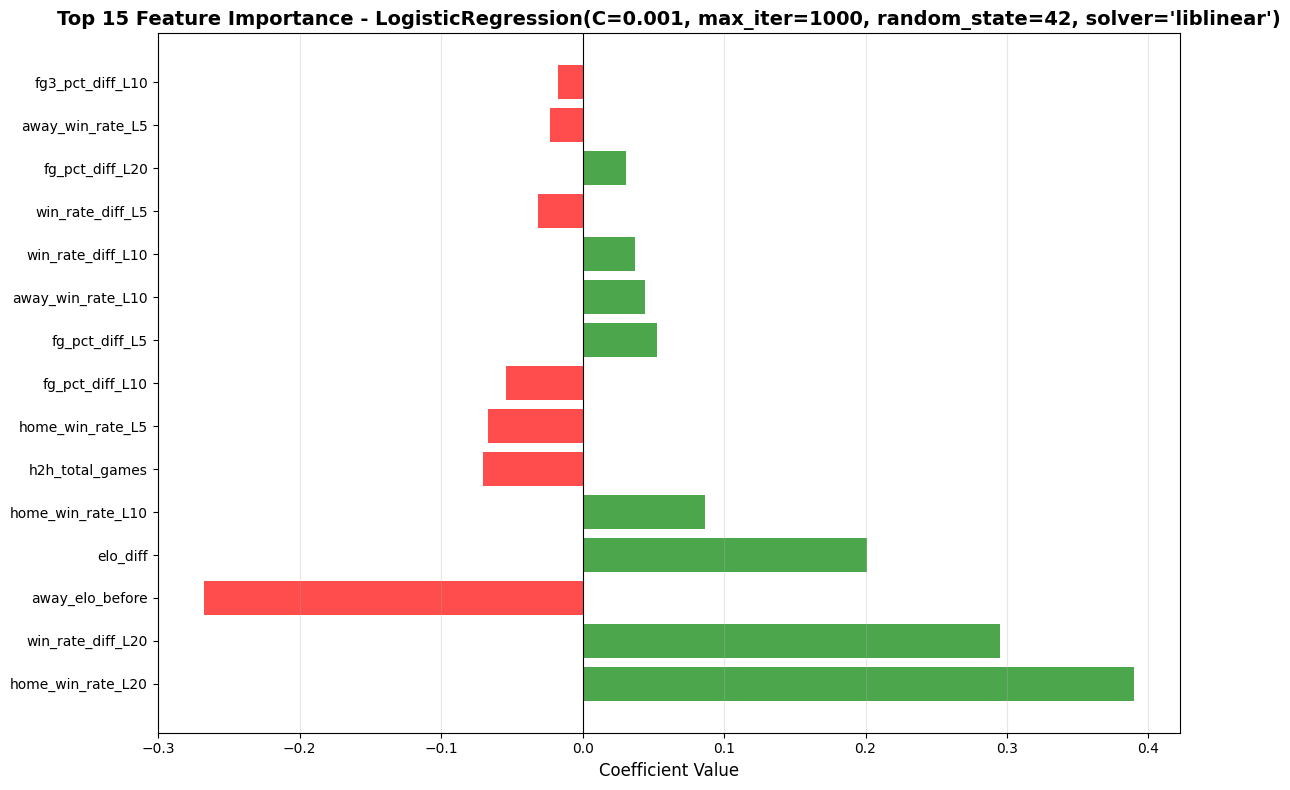

Интерпретация:
  • Положительные коэффициенты (зеленые) увеличивают вероятность победы домашней команды
  • Отрицательные коэффициенты (красные) уменьшают вероятность победы домашней команды


In [49]:
# Визуализация важности признаков
top_features = feature_importance.head(15)

plt.figure(figsize=(12, 8))
colors = ['green' if x > 0 else 'red' for x in top_features['coefficient']]
plt.barh(range(len(top_features)), top_features['coefficient'], color=colors, alpha=0.7)
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Coefficient Value', fontsize=12)
plt.title(f'Top 15 Feature Importance - {best_grid_model}', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("Интерпретация:")
print("  • Положительные коэффициенты (зеленые) увеличивают вероятность победы домашней команды")
print("  • Отрицательные коэффициенты (красные) уменьшают вероятность победы домашней команды")